# IMANI SHANGALUME FABIEN

# REGRESSION LINEAIRE MULTIPLE 

## Données de Mpox de la RDC 

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [156]:
df= pd.read_csv("donnees_mpox_RDC_3000.csv")
df
#epidemioes_RDC.csv

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


In [157]:
print("Aperçu des données épidémiologiques :")
print(df.head(10))

Aperçu des données épidémiologiques :
          ID  Semaine       Province  Pluviometrie_mm  Temperature_C   NDVI  \
0  OBS_00001        1        Mongala              206           24.4  0.480   
1  OBS_00002        2       Kinshasa               56           23.7  0.474   
2  OBS_00003        3       Kinshasa               59           25.2  0.333   
3  OBS_00004        4     Mai-Ndombe              396           24.1  0.354   
4  OBS_00005        5          Kasaï              127           19.8  0.303   
5  OBS_00006        6        Tshuapa              400           20.6  0.721   
6  OBS_00007        7  Kongo Central              181           26.6  0.779   
7  OBS_00008        8         Kwango              356           22.9  0.607   
8  OBS_00009        9         Tshopo              252           30.3  0.527   
9  OBS_00010       10          Kwilu               27           22.1  0.608   

   Humidite_pct  Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
0          

In [158]:
df.columns

Index(['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct'],
      dtype='object')

# 2. Analyse Exploratoire des Données (EDA) Approfondie

In [159]:
# Statistiques descriptives détaillées
print("Statistiques descriptives :")
print(df[['Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque',
       'Taux_Positivite_pct']].describe())

Statistiques descriptives :
       Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count      3000.000000    3000.000000  3000.000000   3000.000000   
mean        157.779667      24.980367     0.451182     71.571667   
std         101.958774       3.832510     0.157799     11.625285   
min           2.000000      18.000000     0.103000     40.000000   
25%          77.000000      22.300000     0.331000     64.000000   
50%         136.000000      24.900000     0.452000     71.500000   
75%         221.000000      27.600000     0.576000     80.000000   
max         400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333                 31.843967      286.143333   
std             95.218460                 14.079517       88.256194   
min              5.000000                  5.600000       90.000000   
25% 

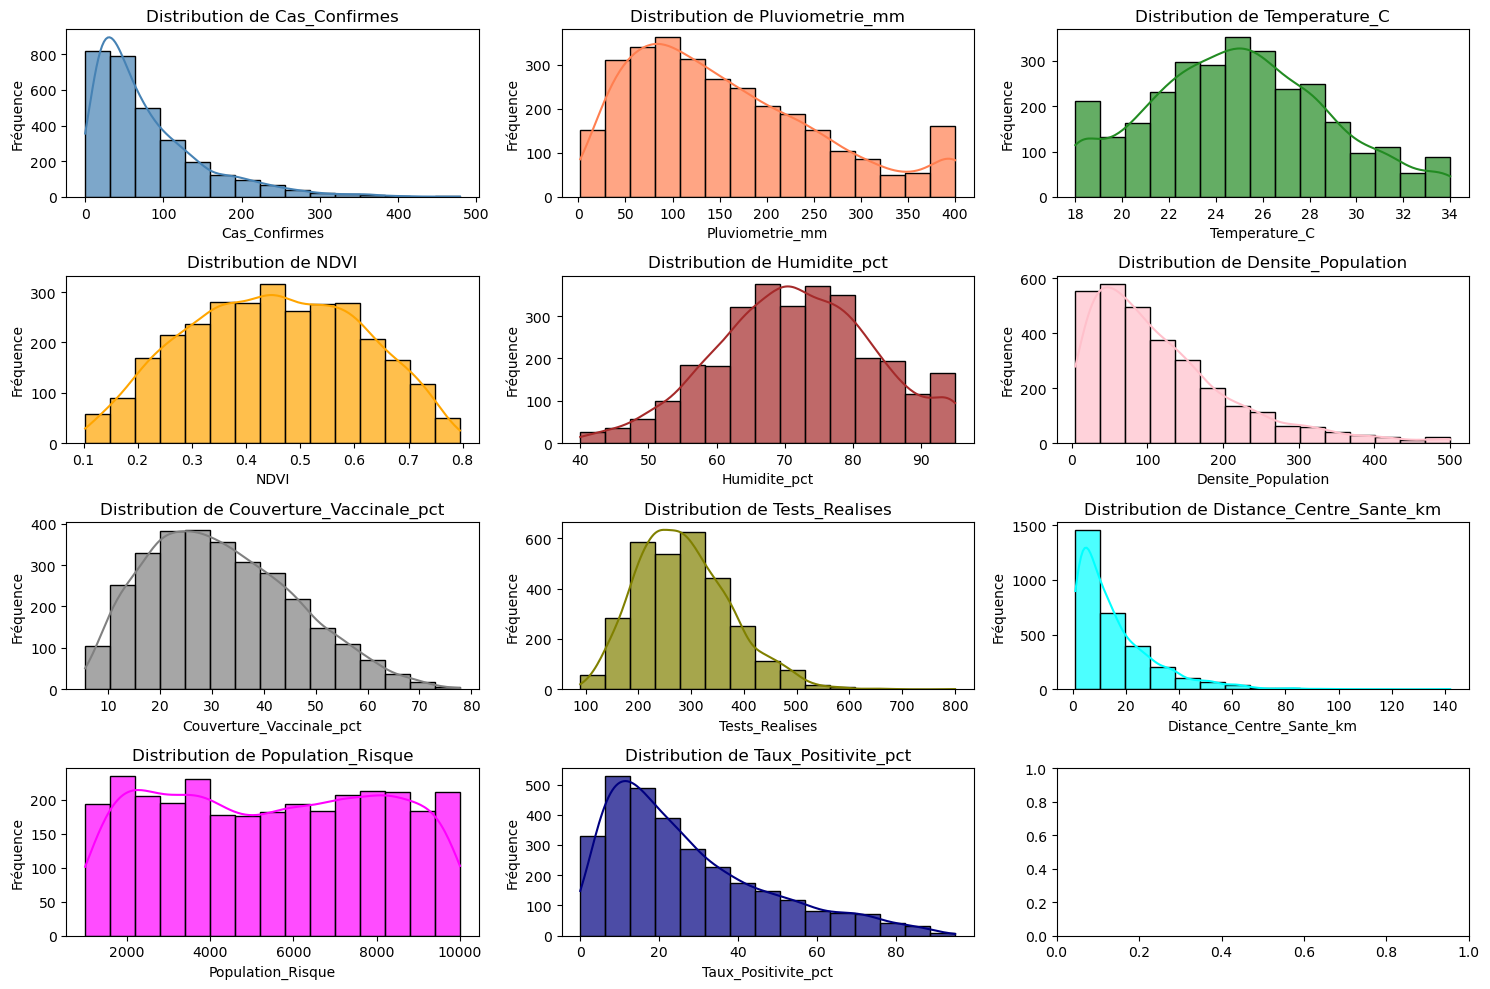

In [160]:


# 4.3. Distribution des variables (Histogrammes + KDE)
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

variables = ['Cas_Confirmes','Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Population_Risque',
       'Taux_Positivite_pct']
couleurs = ['steelblue', 'coral', 'forestgreen', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'navy']

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.histplot(df[var], kde=True, ax=axes[i], color=color, bins=15, alpha=0.7)
    axes[i].set_title(f'Distribution de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

Les cas confirmés, la densité de population, la distance aux centres de santé et le taux de positivité sont majoritairement concentrés sur de faibles valeurs, avec quelques observations élevées. La pluviométrie, la couverture vaccinale et le nombre de tests réalisés présentent principalement des valeurs intermédiaires. La température, le NDVI et l'humidité sont essentiellement répartis autour de leurs valeurs centrales, tandis que la population à risque affiche une répartition relativement homogène sur l'ensemble des observations.

# 2.3. Boxplots pour Détecter les Valeurs Aberrantes

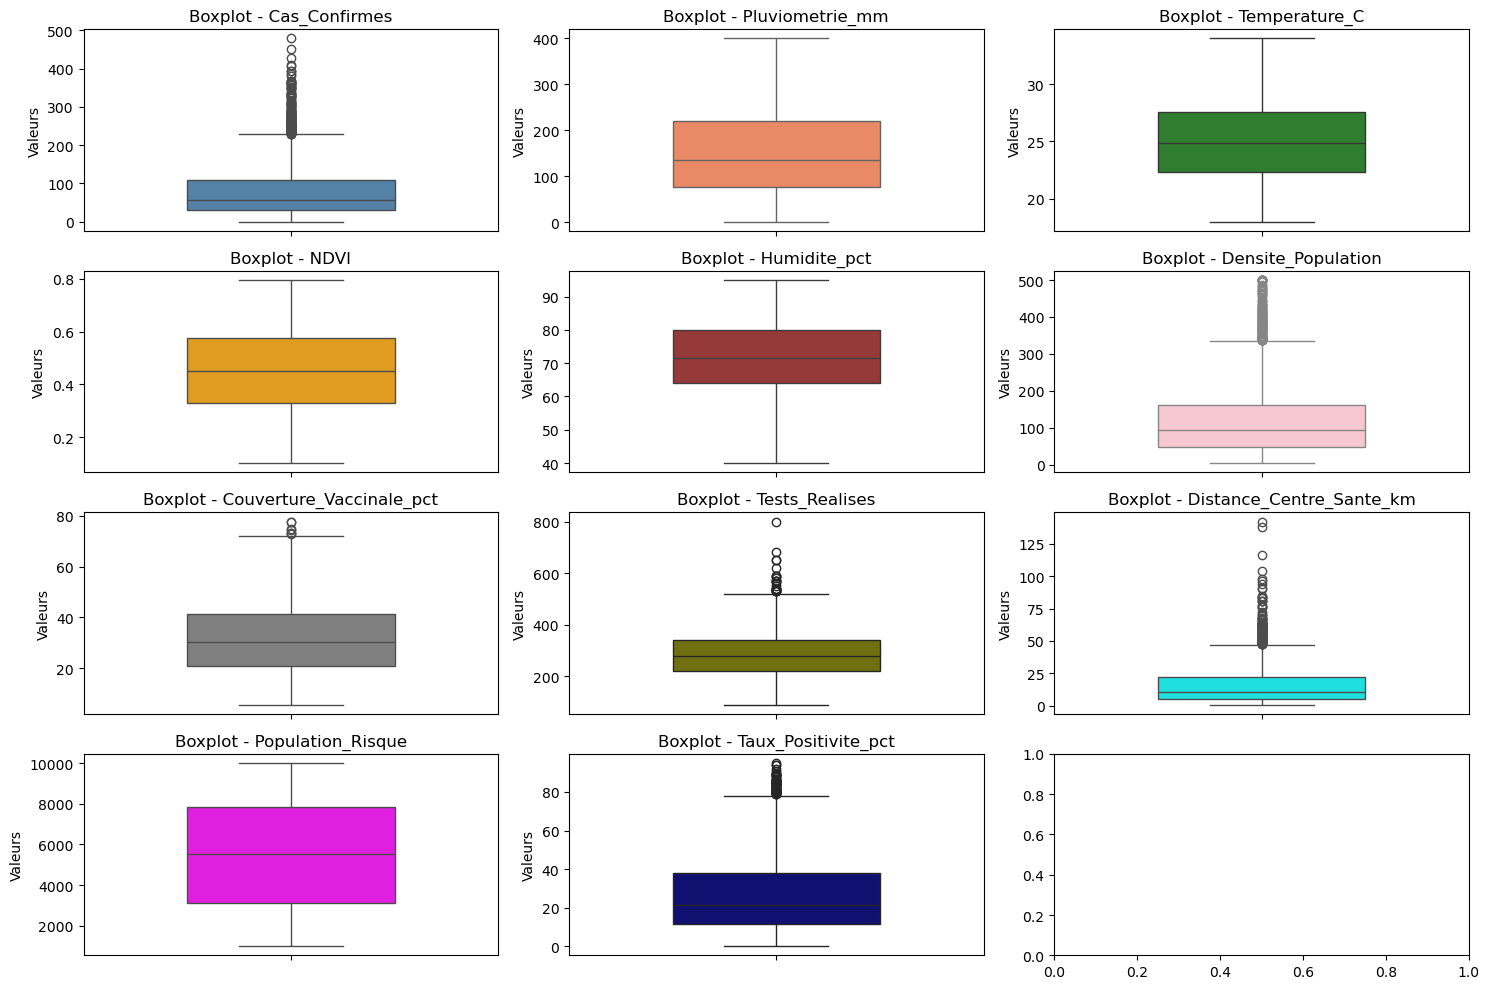

In [161]:
#  Boxplots pour détecter les outliers
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (var, color) in enumerate(zip(variables, couleurs)):
    sns.boxplot(y=df[var], ax=axes[i], color=color, width=0.5)
    axes[i].set_title(f'Boxplot - {var}')
    axes[i].set_ylabel('Valeurs')

plt.tight_layout()
plt.show()

Les boxplots montrent une dispersion modérée pour la température, le NDVI, l'humidité et la population à risque, sans valeurs aberrantes marquées. En revanche, les cas confirmés, la densité de population, le nombre de tests réalisés, la distance au centre de santé, le taux de positivité et, dans une moindre mesure, la couverture vaccinale présentent plusieurs valeurs aberrantes élevées,

# 2.4. Relations entre les cas confirmés, réalisation du test et les variables explicatives contextuelles

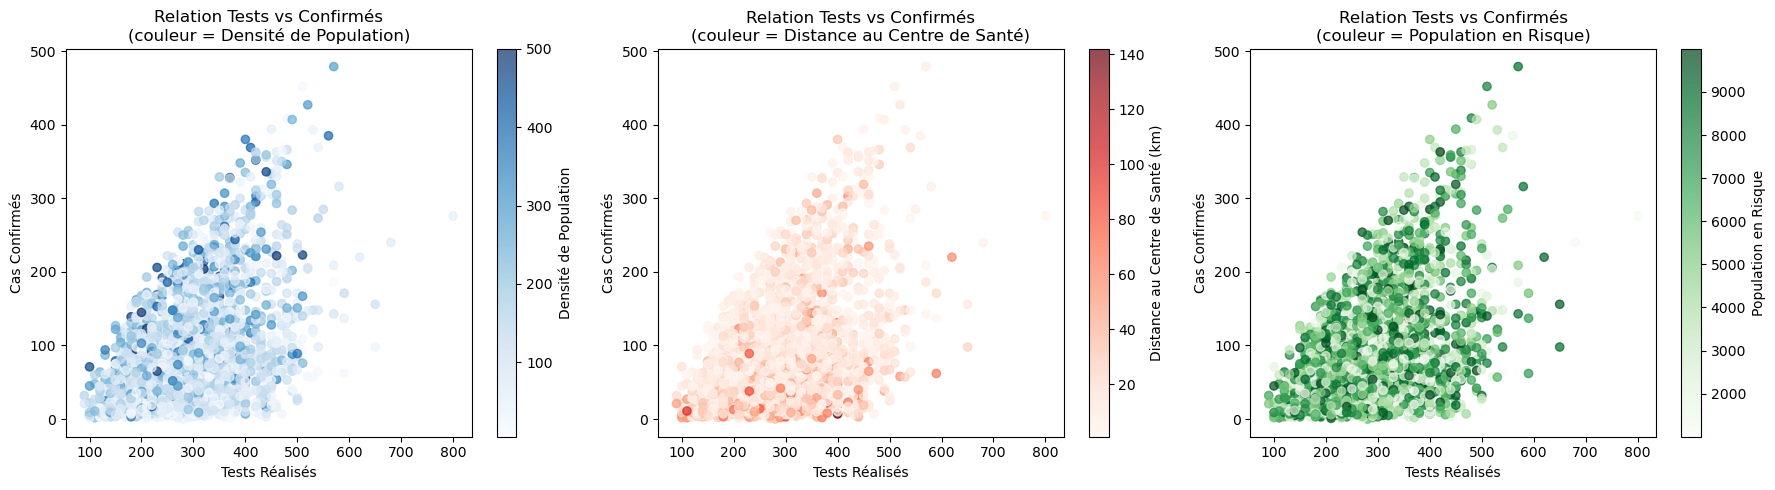

In [162]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot avec couleur selon Densité de Population
scatter1 = axes[0].scatter(df['Tests_Realises'], df['Cas_Confirmes'], 
                          c=df['Densite_Population'], cmap='Blues', alpha=0.7)
axes[0].set_xlabel('Tests Réalisés')
axes[0].set_ylabel('Cas Confirmés')
axes[0].set_title('Relation Tests vs Confirmés\n(couleur = Densité de Population)')
plt.colorbar(scatter1, ax=axes[0], label='Densité de Population')

# Scatter plot avec couleur selon Distance au Centre de Santé
scatter2 = axes[1].scatter(df['Tests_Realises'], df['Cas_Confirmes'], 
                          c=df['Distance_Centre_Sante_km'], cmap='Reds', alpha=0.7)
axes[1].set_xlabel('Tests Réalisés')
axes[1].set_ylabel('Cas Confirmés')
axes[1].set_title('Relation Tests vs Confirmés\n(couleur = Distance au Centre de Santé)')
plt.colorbar(scatter2, ax=axes[1], label='Distance au Centre de Santé (km)')

# Scatter plot avec couleur selon Population en Risque
scatter3 = axes[2].scatter(df['Tests_Realises'], df['Cas_Confirmes'], 
                          c=df['Population_Risque'], cmap='Greens', alpha=0.7)
axes[2].set_xlabel('Tests Réalisés')
axes[2].set_ylabel('Cas Confirmés')
axes[2].set_title('Relation Tests vs Confirmés\n(couleur = Population en Risque)')
plt.colorbar(scatter3, ax=axes[2], label='Population en Risque')

plt.tight_layout()
plt.show()

Il y a une relation proportionnelle entre le nombre de tests réalisés et le nombre de cas confirmés. Les zones effectuant davantage de tests enregistrant généralement un plus grand nombre de cas. Cette tendance est observée quel que soit le niveau de densité de population, la distance au centre de santé ou la taille de la population à risque, bien que les valeurs les plus élevées de cas confirmés soient principalement associées à des contextes où le volume de tests est important.

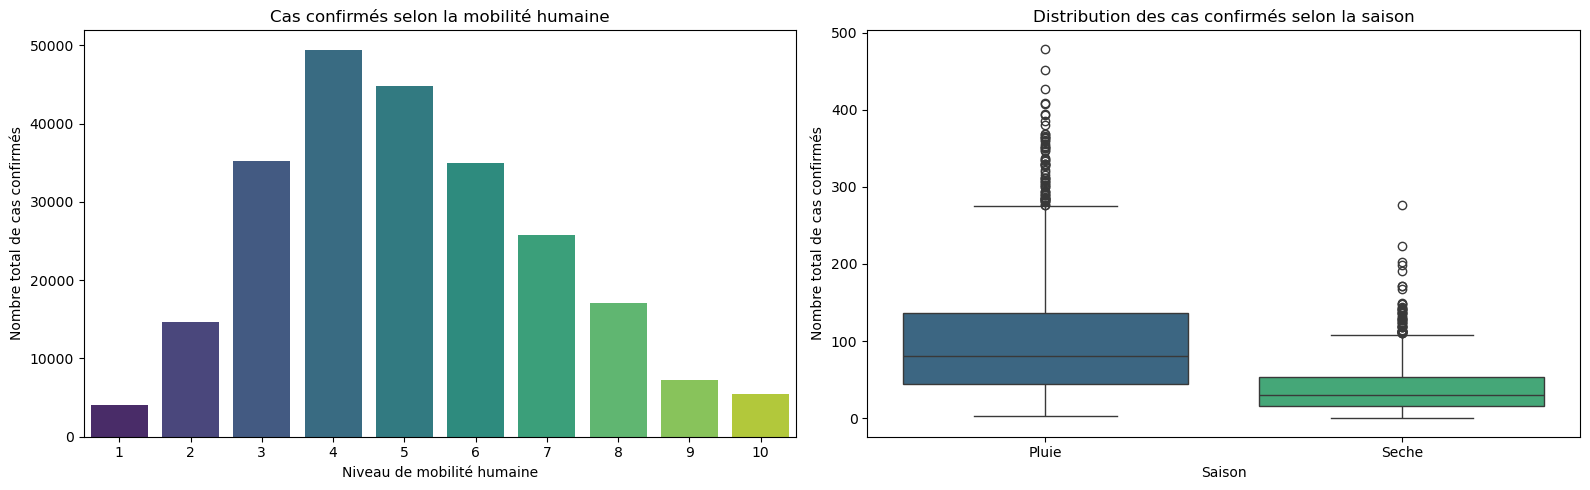

In [163]:

fig, axes = plt.subplots(1, 2, figsize=(16,5))
##  Analyse de la Relation entre la mobilité humaine et les cas confirmés

sns.barplot(data=df.groupby('Mobilite_Humaine', as_index=False)['Cas_Confirmes'].sum(),
            x='Mobilite_Humaine', y='Cas_Confirmes', palette='viridis', ax=axes[0])
axes[0].set_title("Cas confirmés selon la mobilité humaine")
axes[0].set_xlabel("Niveau de mobilité humaine")
axes[0].set_ylabel("Nombre total de cas confirmés")

## Analyse de la Relation entre la saisonalité et les cas confirmés

sns.boxplot(data=df, x='Saison', y='Cas_Confirmes',
            palette='viridis', ax=axes[1])
axes[1].set_title("Distribution des cas confirmés selon la saison")
axes[1].set_xlabel("Saison")
axes[1].set_ylabel("Nombre total de cas confirmés")


plt.tight_layout()
plt.show()

Le nombre total de cas confirmés augmente avec le niveau de mobilité humaine jusqu'au niveau 4, puis diminue progressivement aux niveaux de mobilité plus élevés. Par ailleurs, la distribution des cas confirmés est plus élevée et plus dispersée pendant la saison des pluies que pendant la saison sèche, suggérant une plus grande fréquence des cas et une variabilité accrue durant cette période.

# 2.5. la relation entre les variables environnementales et les cas confirmés

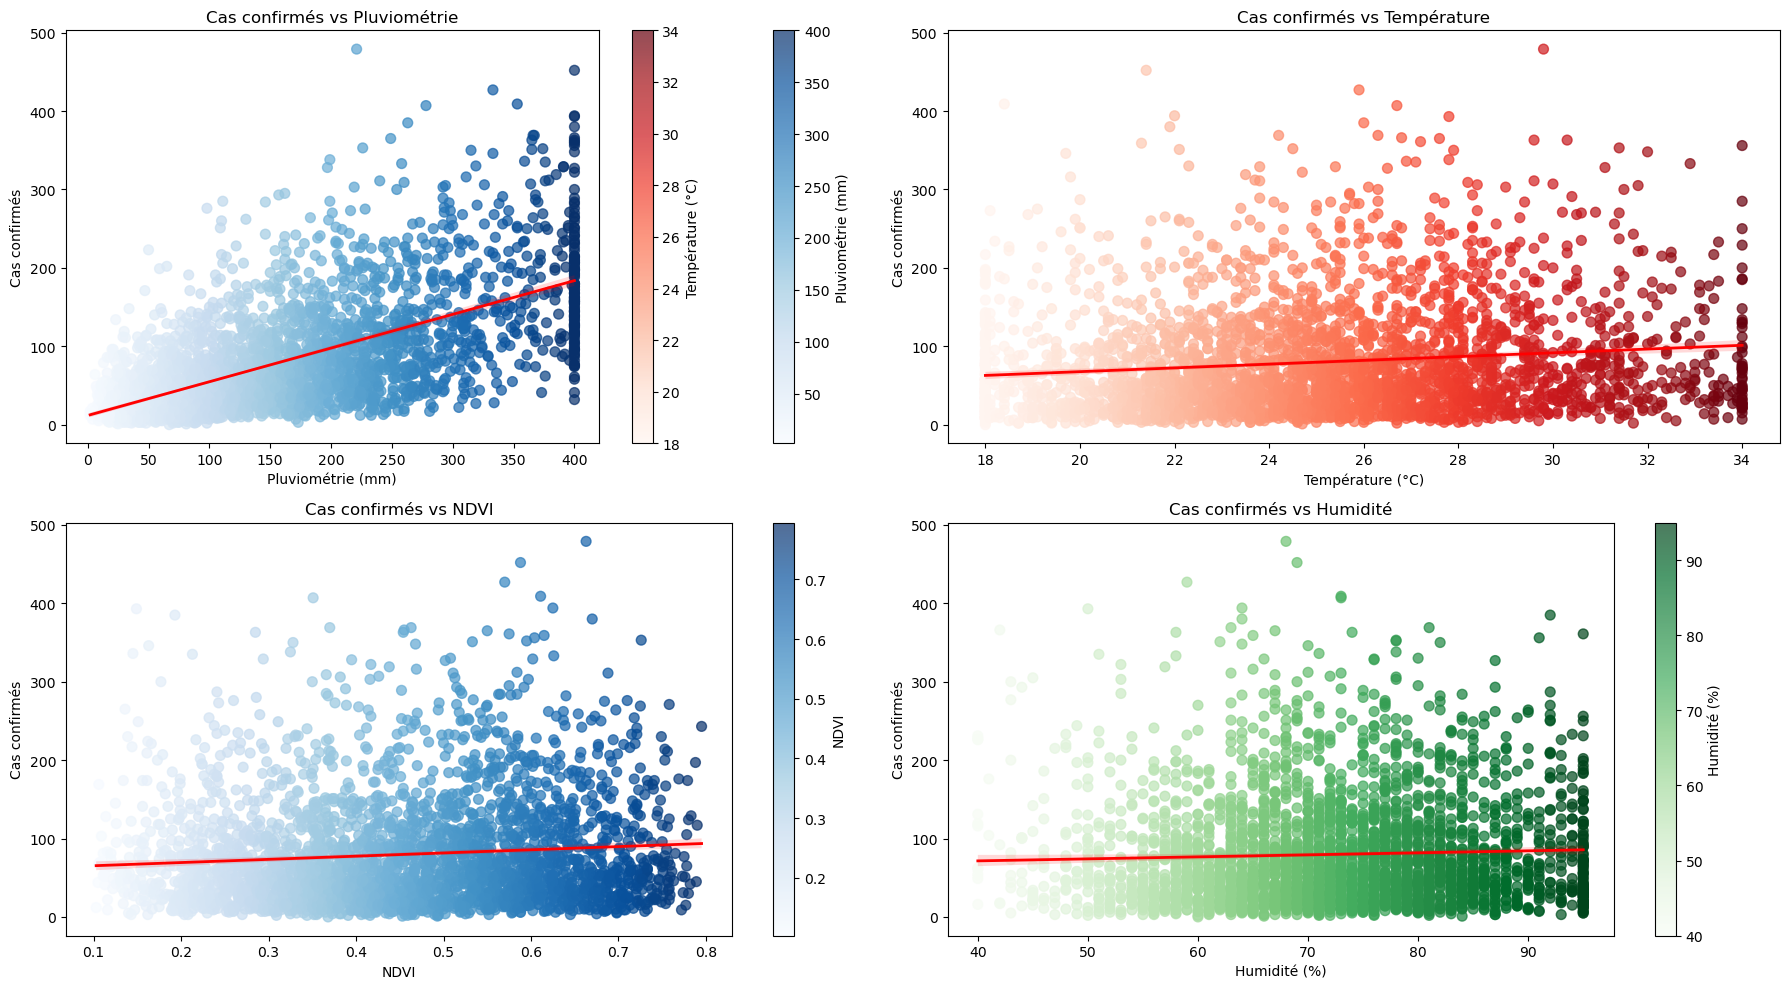

In [164]:

fig, axes = plt.subplots(2, 2, figsize=(18,10))

# Pluviométrie

# Scatter
scatter1 = axes[0,0].scatter(
    df['Pluviometrie_mm'],
    df['Cas_Confirmes'],
    c=df['Pluviometrie_mm'],
    cmap='Blues',
    alpha=0.7,
    s=50
)

# Droite de régression
sns.regplot(
    data=df,
    x='Pluviometrie_mm',
    y='Cas_Confirmes',
    scatter=False,
    ci=95,
    line_kws={'color':'red', 'linewidth':2},
    ax=axes[0,0]
)

axes[0,0].set_xlabel("Pluviométrie (mm)")
axes[0,0].set_ylabel("Cas confirmés")
axes[0,0].set_title("Cas confirmés vs Pluviométrie")

plt.colorbar(scatter1, ax=axes[0,0], label="Pluviométrie (mm)")

# Température

# Scatter
scatter1 = axes[0,1].scatter(
    df['Temperature_C'],
    df['Cas_Confirmes'],
    c=df['Temperature_C'],
    cmap='Reds',
    alpha=0.7,
    s=50
)

# Droite de régression
sns.regplot(
    data=df,
    x='Temperature_C',
    y='Cas_Confirmes',
    scatter=False,
    ci=95,
    line_kws={'color':'red', 'linewidth':2},
    ax=axes[0,1]
)

axes[0,1].set_xlabel("Température (°C)")
axes[0,1].set_ylabel("Cas confirmés")
axes[0,1].set_title("Cas confirmés vs Température")

plt.colorbar(scatter1, ax=axes[0,0], label="Température (°C)")

# NDVI

# Scatter
scatter1 = axes[1,0].scatter(
    df['NDVI'],
    df['Cas_Confirmes'],
    c=df['NDVI'],
    cmap='Blues',
    alpha=0.7,
    s=50
)

# Droite de régression
sns.regplot(
    data=df,
    x='NDVI',
    y='Cas_Confirmes',
    scatter=False,
    ci=95,
    line_kws={'color':'red', 'linewidth':2},
    ax=axes[1,0]
)

axes[1,0].set_xlabel("NDVI")
axes[1,0].set_ylabel("Cas confirmés")
axes[1,0].set_title("Cas confirmés vs NDVI")

plt.colorbar(scatter1, ax=axes[1,0], label="NDVI")


# Humidité

# Scatter
scatter1 = axes[1,1].scatter(
    df['Humidite_pct'],
    df['Cas_Confirmes'],
    c=df['Humidite_pct'],
    cmap='Greens',
    alpha=0.7,
    s=50
)

# Droite de régression
sns.regplot(
    data=df,
    x='Humidite_pct',
    y='Cas_Confirmes',
    scatter=False,
    ci=95,
    line_kws={'color':'red', 'linewidth':2},
    ax=axes[1,1]
)

axes[1,1].set_xlabel("Humidité (%)")
axes[1,1].set_ylabel("Cas confirmés")
axes[1,1].set_title("Cas confirmés vs Humidité")

plt.colorbar(scatter1, ax=axes[1,1], label="Humidité (%)")


plt.tight_layout()
plt.show()

Il y a une relation positive entre le nombre de cas confirmés et les variables climatiques étudiées. Les cas confirmés tendent à augmenter avec l'intensité des précipitations, tandis que la température, le NDVI et l'humidité présentent également une tendance positive, mais moins marquée. Cette association apparaît plus prononcée pour la pluviométrie que pour les autres facteurs environnementaux.

# 2.4. Heatmap de Corrélation

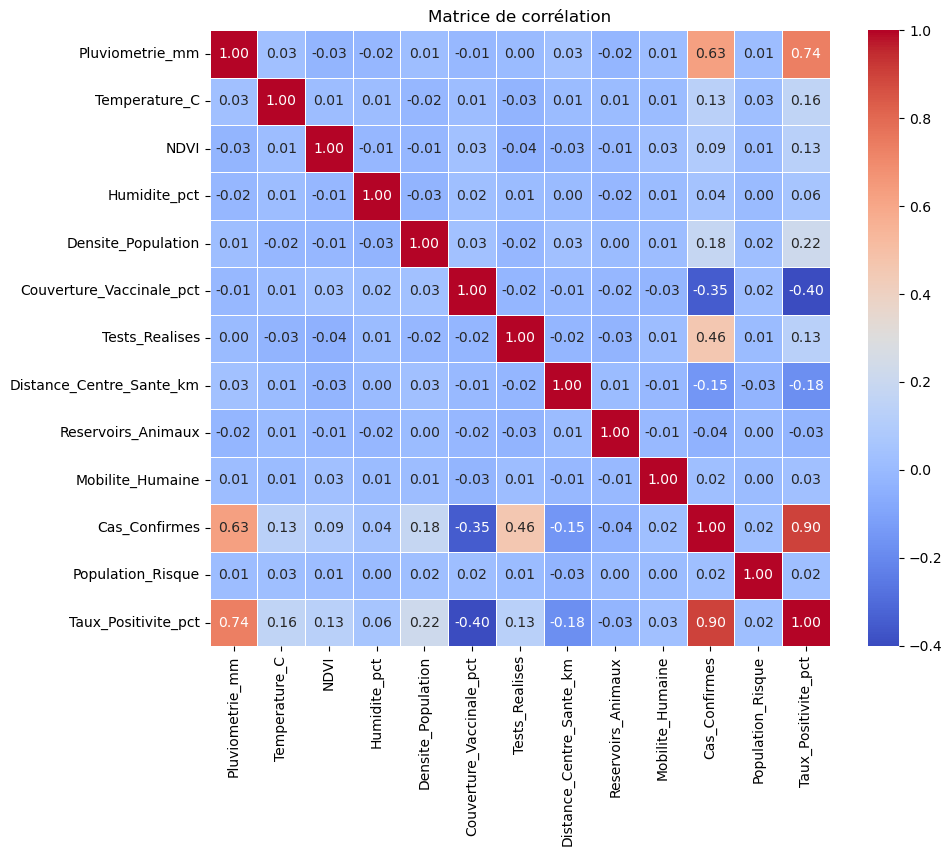

In [165]:
# Calcul de la corrélation
correlation_matrix = df[['Pluviometrie_mm', 'Temperature_C', 'NDVI',
       'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct',
       'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux',
       'Mobilite_Humaine', 'Cas_Confirmes', 'Population_Risque',
       'Taux_Positivite_pct']].corr()

# Visualisation avec une heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation')
plt.show()

La matrice de corrélation met en évidence une forte corrélation positive entre les cas confirmés et le taux de positivité (r = 0,90), ainsi qu'une corrélation positive modérée avec la pluviométrie (r = 0,63) et le nombre de tests réalisés (r = 0,46). Une corrélation négative modérée est observée avec la couverture vaccinale (r = -0,35), tandis que la densité de population (r = 0,18), la température (r = 0,13), le NDVI (r = 0,09) et l'humidité (r = 0,04) présentent des corrélations faibles. La distance au centre de santé est faiblement corrélée négativement aux cas confirmés (r = -0,15), alors que la mobilité humaine, les réservoirs animaux et la population à risque montrent des corrélations négligeables.

# 3. Gestion des valeurs manquantes et des outliers

In [166]:
# Types des variables
df.dtypes

ID                           object
Semaine                       int64
Province                     object
Pluviometrie_mm               int64
Temperature_C               float64
NDVI                        float64
Humidite_pct                  int64
Densite_Population            int64
Couverture_Vaccinale_pct    float64
Tests_Realises                int64
Distance_Centre_Sante_km      int64
Reservoirs_Animaux            int64
Mobilite_Humaine              int64
Cas_Confirmes                 int64
Saison                       object
Population_Risque             int64
Taux_Positivite_pct         float64
dtype: object

In [167]:
# Convertir les variables catégorielles en numériques

from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

In [168]:
df.dtypes

ID                            int64
Semaine                       int64
Province                      int64
Pluviometrie_mm               int64
Temperature_C               float64
NDVI                        float64
Humidite_pct                  int64
Densite_Population            int64
Couverture_Vaccinale_pct    float64
Tests_Realises                int64
Distance_Centre_Sante_km      int64
Reservoirs_Animaux            int64
Mobilite_Humaine              int64
Cas_Confirmes                 int64
Saison                        int64
Population_Risque             int64
Taux_Positivite_pct         float64
dtype: object

In [169]:
# Gestion des valeurs manquantes

isnull_counts = df.isnull().sum()
isnull_counts 

ID                          0
Semaine                     0
Province                    0
Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
Saison                      0
Population_Risque           0
Taux_Positivite_pct         0
dtype: int64

# Gestions des outliers par la normalisation

In [170]:
# Sélection des colonnes numériques
df_num = df.select_dtypes(include=np.number)

# Normalisation
scaler = MinMaxScaler()
df_scaler = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=df_num.columns
)

df_scaler.head()

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,0.000000,0.000000,0.64,0.512563,0.40000,0.544798,0.436364,0.068687,0.362881,0.084507,0.148936,1.0,0.333333,0.060543,0.0,0.275345,0.203474
1,0.000333,0.000333,0.32,0.135678,0.35625,0.536127,0.618182,0.206061,0.267313,0.295775,0.028369,1.0,0.555556,0.087683,1.0,0.301467,0.147368
2,0.000667,0.000667,0.32,0.143216,0.45000,0.332370,0.400000,0.272727,0.668975,0.309859,0.106383,0.0,0.777778,0.041754,1.0,0.425967,0.067895
3,0.001000,0.001000,0.56,0.989950,0.38125,0.362717,0.509091,0.185859,0.281163,0.169014,0.021277,0.0,1.000000,0.171190,0.0,0.308582,0.411053
4,0.001334,0.001334,0.20,0.314070,0.11250,0.289017,0.381818,0.163636,0.342105,0.239437,0.163121,1.0,0.555556,0.050104,0.0,0.933193,0.097158


# 4. MODEL DE REGRESSION MULTIPLE

In [171]:
# Séparation des features et de la target

X = df_scaler.drop(columns=['Cas_Confirmes','Taux_Positivite_pct', 'Semaine', 'ID'])
y = df_scaler['Cas_Confirmes']

# Justification des choix des variables du modèle

Exclusion du taux de positivité afin d'éviter d'introduire une variable fortement corrélée à la variable cible (Cas_Confirmes ) r = 0.9, susceptible de conduire à des performances artificiellement élevées du modèle

In [172]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=20)

In [173]:
from sklearn.linear_model import LinearRegression

model_LRM = LinearRegression()
model_LRM.fit(x_train, y_train)

LinearRegression()

In [174]:
bo = model_LRM.intercept_
bo

np.float64(-0.15189633513428644)

# Interprétation du de l'intercept β₀ du modèle

L'intercept (β₀ = −0,15) représente le nombre de cas confirmés prédit lorsque toutes les variables explicatives sont nulles.

In [175]:
coef = model_LRM.coef_
coef

array([ 0.00067391,  0.37067508,  0.08112185,  0.08642729,  0.0445658 ,
        0.15115848, -0.26466465,  0.54264011, -0.22668439, -0.00339693,
       -0.00363424,  0.01341601,  0.00158454])

In [176]:
pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model_LRM.coef_
})

,Variable,Coefficient
0,Province,0.000674
1,Pluviometrie_mm,0.370675
2,Temperature_C,0.081122
3,NDVI,0.086427
4,Humidite_pct,0.044566
5,Densite_Population,0.151158
6,Couverture_Vaccinale_pct,-0.264665
7,Tests_Realises,0.542640
8,Distance_Centre_Sante_km,-0.226684
9,Reservoirs_Animaux,-0.003397


# Interprétation des coefficients β du modèle 

Les coefficients du modèle montrent que le nombre de tests réalisés (β = 0,543) et la pluviométrie (β = 0,371) sont les variables les plus fortement associées à une augmentation du nombre de cas confirmés. À l'inverse, la couverture vaccinale (β = −0,265) et la distance au centre de santé (β = −0,227) sont associées à une diminution du nombre de cas prédits. Les autres variables présentent des effets relativement faibles sur la prédiction des cas confirmés.

In [177]:
y_pred = model_LRM.predict(x_test)
y_pred

array([ 1.42857783e-01,  1.87860724e-01,  3.11191286e-01,  1.01229566e-01,
        1.63638974e-01, -1.46454105e-02, -1.14004422e-01, -8.43604609e-03,
        3.13764013e-01,  3.10813447e-02,  1.45627678e-01,  3.57777667e-01,
        1.01672937e-02,  3.03016002e-01, -5.32792298e-05,  1.28699646e-01,
        3.16188454e-01,  8.46277496e-02,  5.38558678e-02,  9.18594149e-03,
        2.27207546e-02,  2.22700770e-01,  1.24600786e-01,  1.24263010e-01,
        4.82716980e-01,  1.03942447e-01,  2.30476499e-01,  9.41243978e-02,
        6.35248896e-02,  1.08127256e-01,  2.37632667e-01,  3.04789362e-02,
        1.79270637e-01, -3.41039284e-02,  3.42166252e-02,  2.10128546e-01,
        1.14574454e-01,  3.15657790e-01,  2.54557714e-01,  5.63386387e-02,
        4.19497031e-02,  3.01321213e-01,  9.68873597e-02,  1.05753774e-01,
        1.51197945e-01,  2.02096206e-01,  1.92068396e-01,  2.91453233e-01,
        2.19914233e-01, -2.17411989e-02,  2.08423398e-04,  1.26622915e-01,
       -4.68173052e-02,  

In [178]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import math
print("MSE",mean_squared_error(y_test, y_pred))
print("MAE",mean_absolute_error(y_test, y_pred))
print("RMSE",math.sqrt(mean_squared_error(y_test, y_pred)))
print("R2", r2_score(y_test, y_pred) )

MSE 0.003969692869851331
MAE 0.04602327932605048
RMSE 0.0630054987271058
R2 0.8333196860923746


# Interprétation des métriques d'évaluation du modèle

Le modèle présente de bonnes performances: (R² = 0,833 proche de 1), indique que 83,3 % de la variabilité du nombre de cas confirmés est expliquée par les variables explicatives. Les faibles valeurs du MSE (0,004), du RMSE (0,063) et du MAE (0,046) traduisent des erreurs de prédiction limitées, témoignant d'une bonne précision du modèle.